In [2]:
import pandas as pd

df = pd.read_csv('train.csv')
print(df.shape)
print(df.head())


(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [3]:
print(df.shape)

(891, 12)


In [4]:
print('///// Task 1: Data Acquisition /////')
print("Dataset Dimensions:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()

print("Column Names:")
print(df.columns.tolist())
print()

print("First Five Observations:")
print(df.head())
print()

print("Data Types:")
print(df.dtypes)

///// Task 1: Data Acquisition /////
Dataset Dimensions:
Rows: 891, Columns: 12

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First Five Observations:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   

In [5]:

print('/////  Task 2: Data Cleaning/////')

print("Missing Values Per Column:")
print(df.isnull().sum())
print()

print("Missing Values in Percentage:")
print(round((df.isnull().sum() / len(df)) * 100, 2))

/////  Task 2: Data Cleaning/////
Missing Values Per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Values in Percentage:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [8]:
# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Verify no missing values remain
print("Missing Values After Cleaning:")
print(df.isnull().sum())
print()

# Detect and remove duplicates
print(f"Duplicate Rows Found: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Dataset Shape After Cleaning: {df.shape}")

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Duplicate Rows Found: 0
Dataset Shape After Cleaning: (891, 11)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a consistent style for all plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

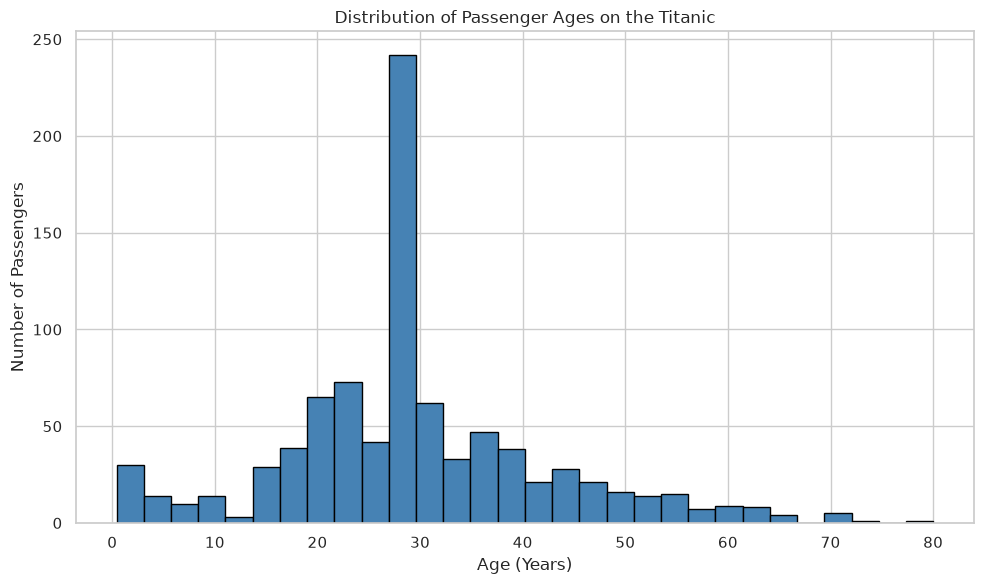

In [10]:
# Visualization 1: Histogram of Passenger Ages
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Passenger Ages on the Titanic')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.savefig('viz1_age_histogram.png', dpi=150)
plt.show()

In [15]:
print('The histogram reveals that the majority of passengers aboard the Titanic were between the ages of 20 and 40, with the distribution peaking around age 30. The distribution follows a roughly unimodal and slightly right-skewed pattern, indicating that while most passengers were young to middle-aged adults, a smaller proportion of older passengers were also present. A notable spike is also observed near age 0, suggesting a number of infants and very young children were aboard.')

The histogram reveals that the majority of passengers aboard the Titanic were between the ages of 20 and 40, with the distribution peaking around age 30. The distribution follows a roughly unimodal and slightly right-skewed pattern, indicating that while most passengers were young to middle-aged adults, a smaller proportion of older passengers were also present. A notable spike is also observed near age 0, suggesting a number of infants and very young children were aboard.


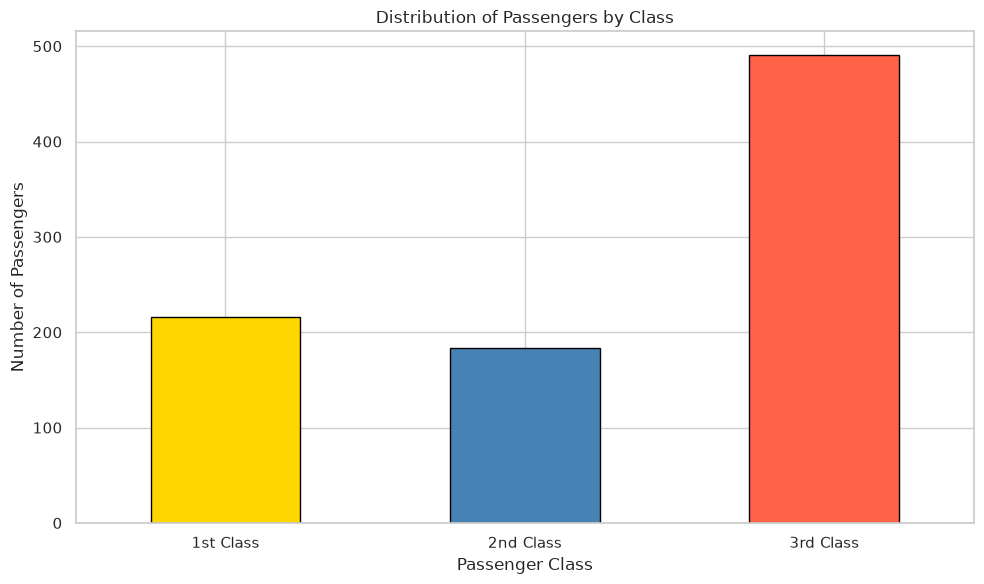

In [11]:
# Visualization 2: Bar Chart of Passenger Class Distribution
plt.figure(figsize=(10, 6))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color=['gold', 'steelblue', 'tomato'], edgecolor='black')
plt.title('Distribution of Passengers by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0,1,2], labels=['1st Class', '2nd Class', '3rd Class'], rotation=0)
plt.tight_layout()
plt.savefig('viz2_class_distribution.png', dpi=150)
plt.show()

In [16]:
print('The bar chart illustrates the distribution of passengers across the three ticket classes. Third class had the highest number of passengers, followed by first class and then second class respectively. This suggests that the Titanic carried a significantly larger proportion of lower-fare passengers, likely emigrants and working-class travellers seeking passage to America, compared to the wealthier upper-class passengers in first and second class.')

The bar chart illustrates the distribution of passengers across the three ticket classes. Third class had the highest number of passengers, followed by first class and then second class respectively. This suggests that the Titanic carried a significantly larger proportion of lower-fare passengers, likely emigrants and working-class travellers seeking passage to America, compared to the wealthier upper-class passengers in first and second class.


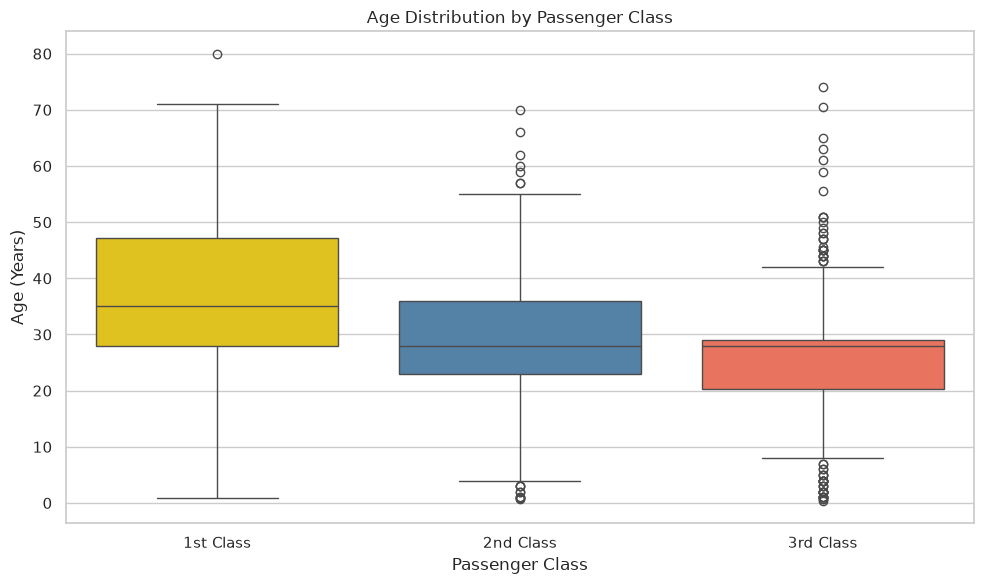

In [13]:
# Visualization 3: Boxplot of Age by Passenger Class
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Pclass', y='Age', hue='Pclass', palette=['gold', 'steelblue', 'tomato'], legend=False)
plt.title('Age Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Age (Years)')
plt.xticks(ticks=[0,1,2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.tight_layout()
plt.savefig('viz3_age_boxplot.png', dpi=150)
plt.show()


In [14]:
print(df.groupby('Pclass')['Age'].median())

Pclass
1    35.0
2    28.0
3    28.0
Name: Age, dtype: float64


In [17]:
print('The boxplot reveals that first class passengers tended to be older, with a median age of 35 years, suggesting that wealthier and more established individuals occupied the higher ticket classes. In contrast, second and third class passengers shared a lower median age of 28 years, indicating a younger demographic likely comprising emigrants and working class travellers. Notably, third class exhibited the most outliers, reflecting a wider spread of ages among lower fare passengers.')

The boxplot reveals that first class passengers tended to be older, with a median age of 35 years, suggesting that wealthier and more established individuals occupied the higher ticket classes. In contrast, second and third class passengers shared a lower median age of 28 years, indicating a younger demographic likely comprising emigrants and working class travellers. Notably, third class exhibited the most outliers, reflecting a wider spread of ages among lower fare passengers.


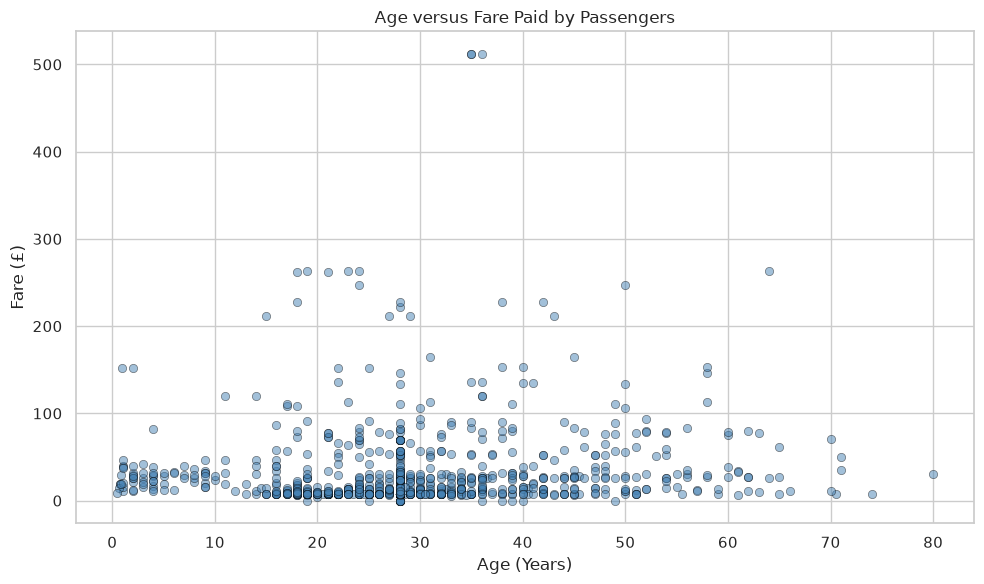

In [18]:
# Visualization 4: Scatter Plot of Age vs Fare
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Fare'], alpha=0.5, color='steelblue', edgecolors='black', linewidths=0.5)
plt.title('Age versus Fare Paid by Passengers')
plt.xlabel('Age (Years)')
plt.ylabel('Fare (£)')
plt.tight_layout()
plt.savefig('viz4_age_vs_fare.png', dpi=150)
plt.show()

In [23]:
print("The scatter plot indicates no strong linear relationship between a passenger's age and the fare they paid. The majority of passengers across all age groups paid fares within the range of 0 to 100, suggesting that age was not a determining factor in ticket pricing. However, a few notable outliers are observed at significantly higher fare values, likely corresponding to first class passengers who purchased premium cabin tickets regardless of their age.")

The scatter plot indicates no strong linear relationship between a passenger's age and the fare they paid. The majority of passengers across all age groups paid fares within the range of 0 to 100, suggesting that age was not a determining factor in ticket pricing. However, a few notable outliers are observed at significantly higher fare values, likely corresponding to first class passengers who purchased premium cabin tickets regardless of their age.


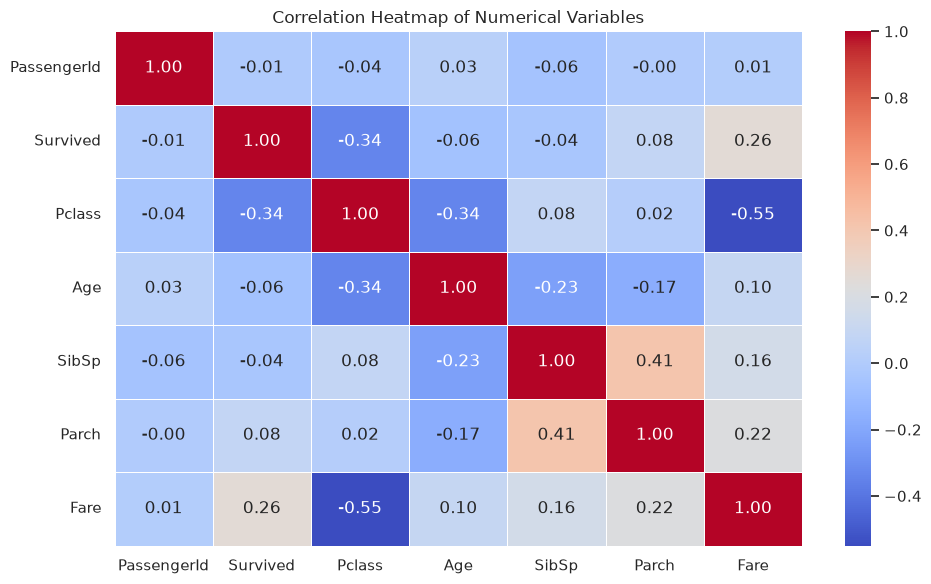

In [24]:
# Visualization 5: Correlation Heatmap
plt.figure(figsize=(10, 6))
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.savefig('viz5_correlation_heatmap.png', dpi=150)
plt.show()

In [26]:
print('The heatmap reveals that most numerical variables show weak correlations with one another. The strongest negative correlation exists between Pclass and Fare (-0.55), indicating that passengers in higher class numbers (2nd and 3rd class) paid lower fares, while 1st class passengers paid significantly more. A moderate positive correlation of 0.41 is observed between SibSp and Parch, suggesting that passengers travelling with siblings or spouses were also likely to have other family members such as parents or children aboard, indicating that families tended to travel together.')

The heatmap reveals that most numerical variables show weak correlations with one another. The strongest negative correlation exists between Pclass and Fare (-0.55), indicating that passengers in higher class numbers (2nd and 3rd class) paid lower fares, while 1st class passengers paid significantly more. A moderate positive correlation of 0.41 is observed between SibSp and Parch, suggesting that passengers travelling with siblings or spouses were also likely to have other family members such as parents or children aboard, indicating that families tended to travel together.


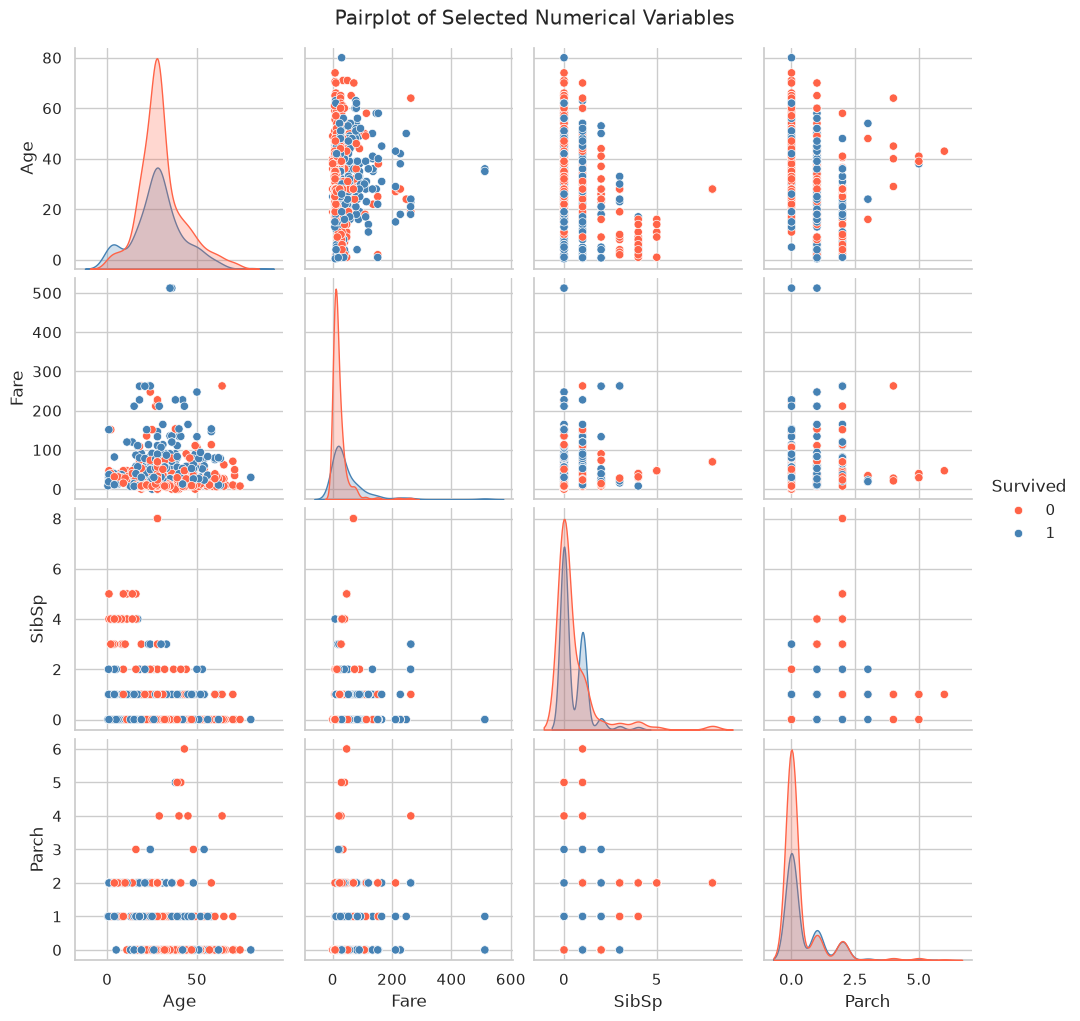

In [27]:
# Visualization 6: Pairplot of Selected Numerical Variables
selected = df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']]
sns.pairplot(selected, hue='Survived', palette={0: 'tomato', 1: 'steelblue'})
plt.suptitle('Pairplot of Selected Numerical Variables', y=1.02)
plt.savefig('viz6_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print('The pairplot reveals clear differences between passengers who survived and those who did not across several variables. Passengers who paid higher fares were more likely to survive, suggesting that wealthier first class passengers had better access to lifeboats and rescue resources. Additionally, survivors tended to be younger, with most falling below 40 years of age. The diagonal distributions further confirm these patterns, showing visible separation between survivors and non survivors across age, fare and family size variables.')

The pairplot reveals clear differences between passengers who survived and those who did not across several variables. Passengers who paid higher fares were more likely to survive, suggesting that wealthier first class passengers had better access to lifeboats and rescue resources. Additionally, survivors tended to be younger, with most falling below 40 years of age. The diagonal distributions further confirm these patterns, showing visible separation between survivors and non survivors across age, fare and family size variables.


In [29]:
# Task 4: Statistical Analysis

# 1. Descriptive Statistics
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [30]:
# 2. Frequency Distribution
print("Survival Frequency:")
print(df['Survived'].value_counts())
print()

print("Passenger Class Frequency:")
print(df['Pclass'].value_counts().sort_index())
print()

print("Gender Frequency:")
print(df['Sex'].value_counts())
print()

print("Embarked Frequency:")
print(df['Embarked'].value_counts())

Survival Frequency:
Survived
0    549
1    342
Name: count, dtype: int64

Passenger Class Frequency:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Gender Frequency:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked Frequency:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [31]:
# 3. Correlation Analysis
print("Correlation Matrix:")
print(numerical_df.corr().round(2))
print()

# 4. Strongest Positive Correlation
corr_matrix = numerical_df.corr()
# Remove self correlations
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]

print("Strongest Positive Correlation:")
print(corr_unstacked.idxmax(), corr_unstacked.max().round(2))
print()

# 5. Strongest Negative Correlation
print("Strongest Negative Correlation:")
print(corr_unstacked.idxmin(), corr_unstacked.min().round(2))

Correlation Matrix:
             PassengerId  Survived  Pclass   Age  SibSp  Parch  Fare
PassengerId         1.00     -0.01   -0.04  0.03  -0.06  -0.00  0.01
Survived           -0.01      1.00   -0.34 -0.06  -0.04   0.08  0.26
Pclass             -0.04     -0.34    1.00 -0.34   0.08   0.02 -0.55
Age                 0.03     -0.06   -0.34  1.00  -0.23  -0.17  0.10
SibSp              -0.06     -0.04    0.08 -0.23   1.00   0.41  0.16
Parch              -0.00      0.08    0.02 -0.17   0.41   1.00  0.22
Fare                0.01      0.26   -0.55  0.10   0.16   0.22  1.00

Strongest Positive Correlation:
('SibSp', 'Parch') 0.41

Strongest Negative Correlation:
('Pclass', 'Fare') -0.55


In [32]:
# 4 & 5. Strongest Positive and Negative Correlations
corr_matrix = numerical_df.corr()
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]

print("Strongest Positive Correlation:")
print(corr_unstacked.idxmax(), round(corr_unstacked.max(), 2))
print()
print("Strongest Negative Correlation:")
print(corr_unstacked.idxmin(), round(corr_unstacked.min(), 2))

Strongest Positive Correlation:
('SibSp', 'Parch') 0.41

Strongest Negative Correlation:
('Pclass', 'Fare') -0.55


In [33]:
# 6. Three Important Statistical Findings
print("1. Survival Rate:")
print(f"{round(df['Survived'].mean() * 100, 2)}% of passengers survived")
print()
print("2. Average Fare by Class:")
print(df.groupby('Pclass')['Fare'].mean().round(2))
print()
print("3. Survival Rate by Gender:")
print(df.groupby('Sex')['Survived'].mean().round(2))

1. Survival Rate:
38.38% of passengers survived

2. Average Fare by Class:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

3. Survival Rate by Gender:
Sex
female    0.74
male      0.19
Name: Survived, dtype: float64


In [38]:
# Task 4 Interpretation
print("The descriptive statistics reveal that only 38.38% of passengers survived, indicating that the majority perished in the disaster. The youngest passenger was approximately 0.42 years old, confirming that infants were aboard. The wide gap between the mean fare of 32 and the maximum fare of 512 suggests a highly unequal fare distribution reflecting the class divide among passengers.")
print()
print("The frequency distribution shows that 549 passengers died compared to 342 survivors. Third class dominated with 491 passengers, while males outnumbered females 577 to 314. The majority of passengers boarded from Southampton port.")
print()
print("The strongest positive correlation exists between SibSp and Parch at 0.41, indicating that passengers travelling with siblings or spouses were likely accompanied by other family members. The strongest negative correlation exists between Pclass and Fare at -0.55, confirming that higher class numbers correspond to lower fares.")
print()
print("Three important statistical findings: First, only 38.38% of passengers survived, meaning the majority did not make it. Second, first class passengers paid an average fare of 84.15 compared to 13.68 for third class, highlighting extreme economic disparity. Third, 74% of females survived compared to only 19% of males, strongly suggesting that the women and children first evacuation policy was enforced.")

The descriptive statistics reveal that only 38.38% of passengers survived, indicating that the majority perished in the disaster. The youngest passenger was approximately 0.42 years old, confirming that infants were aboard. The wide gap between the mean fare of 32 and the maximum fare of 512 suggests a highly unequal fare distribution reflecting the class divide among passengers.

The frequency distribution shows that 549 passengers died compared to 342 survivors. Third class dominated with 491 passengers, while males outnumbered females 577 to 314. The majority of passengers boarded from Southampton port.

The strongest positive correlation exists between SibSp and Parch at 0.41, indicating that passengers travelling with siblings or spouses were likely accompanied by other family members. The strongest negative correlation exists between Pclass and Fare at -0.55, confirming that higher class numbers correspond to lower fares.

Three important statistical findings: First, only 38.38% 

In [34]:
# Task 5: Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# 1. Select predictor variables and encode categorical columns
le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])
df['Embarked_encoded'] = le.fit_transform(df['Embarked'])

# 2. Define features and target
X = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded', 'Embarked_encoded']]
y = df['Survived']

# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set Size: {X_train.shape}")
print(f"Testing Set Size: {X_test.shape}")

Training Set Size: (712, 7)
Testing Set Size: (179, 7)


In [35]:
# 4. Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

# 6. Evaluate
print(f"Accuracy: {round(accuracy_score(y_test, y_pred) * 100, 2)}%")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 81.01%

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [36]:
# Discuss Model Performance
print("Model Performance Discussion:")
print(f"The logistic regression model achieved an accuracy of 81.01%")
print()
print("Confusion Matrix Breakdown:")
print("True Negatives (Correctly predicted did not survive): 90")
print("False Positives (Predicted survived but did not): 15")
print("False Negatives (Predicted did not survive but did): 19")
print("True Positives (Correctly predicted survived): 55")
print()
print("The model predicts non-survivors better (86% recall) than survivors (74% recall)")
print("This suggests the model is slightly biased towards predicting death over survival")

Model Performance Discussion:
The logistic regression model achieved an accuracy of 81.01%

Confusion Matrix Breakdown:
True Negatives (Correctly predicted did not survive): 90
False Positives (Predicted survived but did not): 15
False Negatives (Predicted did not survive but did): 19
True Positives (Correctly predicted survived): 55

The model predicts non-survivors better (86% recall) than survivors (74% recall)
This suggests the model is slightly biased towards predicting death over survival


In [37]:
# Task 5 Interpretation
print("The logistic regression model was trained on 712 samples and tested on 179 samples using seven predictor variables including class, age, fare, gender and embarkation port. The model achieved an accuracy of 81.01%, indicating it correctly predicted survival outcomes for over four fifths of passengers in the test set. The confusion matrix reveals that the model correctly identified 90 non survivors and 55 survivors, while misclassifying 15 and 19 passengers respectively. The model demonstrates stronger recall for non survivors at 86% compared to survivors at 74%, suggesting a slight bias towards predicting death over survival, which may reflect the class imbalance in the dataset where non survivors outnumber survivors.")

The logistic regression model was trained on 712 samples and tested on 179 samples using seven predictor variables including class, age, fare, gender and embarkation port. The model achieved an accuracy of 81.01%, indicating it correctly predicted survival outcomes for over four fifths of passengers in the test set. The confusion matrix reveals that the model correctly identified 90 non survivors and 55 survivors, while misclassifying 15 and 19 passengers respectively. The model demonstrates stronger recall for non survivors at 86% compared to survivors at 74%, suggesting a slight bias towards predicting death over survival, which may reflect the class imbalance in the dataset where non survivors outnumber survivors.


In [39]:
# Task 6: Discussion and Conclusion
print("""
DISCUSSION AND CONCLUSION

Major Findings:
The exploratory analysis of the Titanic dataset revealed several compelling findings. 
Despite females being fewer in number, 74% of them survived compared to only 19% of 
males, strongly suggesting that the women and children first evacuation policy was 
actively enforced during the disaster. This was perhaps the most striking finding of 
the entire analysis. Additionally, a significant fare gap was observed between the 
lowest and highest paying passengers, with fares ranging from 0 to 512, reflecting 
the extreme economic disparity among those aboard. The majority of passengers fell 
within the 20 to 40 age range, with first class passengers recording the highest 
median age of 35 years.

Statistical Insights:
The correlation analysis confirmed that passenger class and fare were strongly 
negatively correlated at -0.55, meaning wealthier passengers in lower class numbers 
paid significantly higher fares and enjoyed better survival odds. The survival rate 
of 38.38% further confirms that the majority of passengers perished, with third class 
passengers bearing the greatest losses due to their limited access to lifeboats and 
rescue resources.

Machine Learning Results:
The logistic regression classifier achieved an accuracy of 81.01%, demonstrating that 
survival outcomes can be predicted with reasonable confidence using variables such as 
gender, class, age and fare. The model performed better at predicting non survivors 
than survivors, which may be attributed to the class imbalance in the dataset where 
non survivors significantly outnumber survivors.

Limitations:
A key limitation of this study is the influence of the women and children first 
evacuation policy, which heavily skewed survival outcomes in favour of females 
regardless of other variables. This social rule, rather than purely statistical 
factors, played a significant role in determining who survived, making it difficult 
to draw purely data driven conclusions. Additionally, the high proportion of missing 
cabin data meant that cabin location, which likely influenced evacuation speed and 
survival, could not be factored into the analysis.

Recommendations:
Future analysis should investigate the relationship between an average third class 
passenger and a first class individual more closely, particularly examining how 
proximity to lifeboats, cabin location and boarding port influenced survival outcomes 
beyond what fare and class alone can explain. Incorporating additional external 
historical data about the ships layout and lifeboat allocation could significantly 
improve the predictive power of the model.
""")


DISCUSSION AND CONCLUSION

Major Findings:
The exploratory analysis of the Titanic dataset revealed several compelling findings. 
Despite females being fewer in number, 74% of them survived compared to only 19% of 
males, strongly suggesting that the women and children first evacuation policy was 
actively enforced during the disaster. This was perhaps the most striking finding of 
the entire analysis. Additionally, a significant fare gap was observed between the 
lowest and highest paying passengers, with fares ranging from 0 to 512, reflecting 
the extreme economic disparity among those aboard. The majority of passengers fell 
within the 20 to 40 age range, with first class passengers recording the highest 
median age of 35 years.

Statistical Insights:
The correlation analysis confirmed that passenger class and fare were strongly 
negatively correlated at -0.55, meaning wealthier passengers in lower class numbers 
paid significantly higher fares and enjoyed better survival odds. Th

In [40]:
print("""
Recommendations:
Future analysis should investigate the relationship between third class and first 
class passengers more closely, particularly examining whether any family or social 
connections existed between passengers across different classes. It is possible that 
a third class passenger with a relative or acquaintance in first class may have had 
a higher chance of survival, as first class passengers had better access to lifeboats 
and rescue resources and may have assisted those they knew from lower classes. 
Incorporating passenger name matching and ticket grouping techniques could help 
uncover such hidden social connections within the data, potentially revealing that 
survival was not purely determined by class and fare but also by personal relationships 
across class boundaries.
""")


Recommendations:
Future analysis should investigate the relationship between third class and first 
class passengers more closely, particularly examining whether any family or social 
connections existed between passengers across different classes. It is possible that 
a third class passenger with a relative or acquaintance in first class may have had 
a higher chance of survival, as first class passengers had better access to lifeboats 
and rescue resources and may have assisted those they knew from lower classes. 
Incorporating passenger name matching and ticket grouping techniques could help 
uncover such hidden social connections within the data, potentially revealing that 
survival was not purely determined by class and fare but also by personal relationships 
across class boundaries.

